# 01 · The Deterministic Accounting Core

### Why a probabilistic engine keeps its accounting *deterministic*

This is the foundational tutorial for the **Probabilistic Financial Forecasting &
Hybrid Accounting Engine**. The whole architecture rests on one split:

> **Uncertainty lives upstream** (simulated macro drivers), **the accounting math
> stays 100 % deterministic and auditable.** Same inputs → same statements, every time.

That is what lets us claim GAAP-style auditability *and* Monte-Carlo tail-risk in
the same system. This notebook builds the deterministic core (`fce.accounting`)
from the ground up and shows the three properties that make it trustworthy:

1. **FCFF** is computed by the canonical capital-budgeting identity.
2. The **3-statement model balances by construction** — not by luck or a plug.
3. **Golden identity tests** (`assert_balanced`) guard that promise on every path.

Then we scale from one path to 10,000 and read off an NPV distribution.

---
*Content reviewed against the local **textbook-kb**; grounding citations appear
inline and are collected in the References section at the end.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from fce.accounting import build_statements, assert_balanced, npv
from fce.accounting.identities import AccountingIdentityError

np.set_printoptions(precision=2, suppress=True)
plt.rcParams["figure.figsize"] = (8, 4)

## 1 · Free Cash Flow to the Firm (FCFF)

Unlevered free cash flow — the cash the whole firm generates before financing —
is what we ultimately discount to NPV. The engine uses the standard identity:

$$\text{FCFF} = \underbrace{\text{EBIT}\,(1-\tau)}_{\text{NOPAT}} + \text{Depreciation} - \text{CapEx} - \Delta\text{NWC}$$

This is exactly **Berk & DeMarzo, *Corporate Finance* (2024), Eq. 8.6 (p. 254)**,
which rearranges the free-cash-flow definition to expose the *depreciation tax
shield* $\tau \times \text{Depreciation}$: depreciation is non-cash, so its only
cash effect is reducing taxable income. Our `build_statements` computes FCFF this
exact way (`fce/accounting/statements.py`).

In [2]:
# One project, one period — a hand-checkable slice.
revenue = 100.0        # $M
opex    = 55.0
dep     = 4.0
capex   = 6.0
d_nwc   = 2.0
tax     = 0.23

ebit  = revenue - opex - dep
nopat = ebit * (1 - tax)
fcff  = nopat + dep - capex - d_nwc
print(f"EBIT   = {ebit:6.2f}")
print(f"NOPAT  = {nopat:6.2f}   (EBIT x (1 - tau))")
print(f"FCFF   = {fcff:6.2f}   (NOPAT + Dep - CapEx - dNWC)")

EBIT   =  41.00
NOPAT  =  31.57   (EBIT x (1 - tau))
FCFF   =  27.57   (NOPAT + Dep - CapEx - dNWC)


In [3]:
# The engine reproduces the same number (shaped (paths=1, periods=1)).
stmt = build_statements(
    revenue=np.array([[revenue]]), opex=np.array([[opex]]),
    depreciation=np.array([[dep]]), capex=np.array([[capex]]),
    delta_nwc=np.array([[d_nwc]]), interest=np.array([[1.5]]),
    net_debt_issued=np.array([[0.0]]), tax_rate=tax,
)
print("engine FCFF =", float(stmt.fcff[0, 0]))
assert np.isclose(stmt.fcff[0, 0], fcff)

engine FCFF = 27.57


## 2 · The 3-statement model balances *by construction*

The balance-sheet identity is the bedrock accounting equation:

$$\text{Assets} = \text{Liabilities} + \text{Equity}, \qquad
\text{Equity} = \underbrace{\text{Contributed Capital}}_{\text{common stock}} + \text{Retained Earnings}$$

(Berk & DeMarzo pp. 31, 63–64; Subramanyam, *Financial Statement Analysis*,
11e, p. 39 — equity = contributed capital + accumulated retained earnings.)

A naive model "plugs" a number to force the balance sheet to tie. We don't. The
engine solves the *opening* common stock once so the starting balance sheet
balances, then rolls everything forward. Each period the change in assets equals
the change in the right-hand side **identically**:

$$\Delta\text{Cash} = \text{CFO} + \text{CFI} + \text{CFF}
= (\text{NI} + \text{Dep} - \Delta\text{NWC}) + (-\text{CapEx}) + (\text{NetDebt} - \text{Div})$$

$$\Delta\text{Assets} = \Delta\text{Cash} + \Delta\text{NWC} + (\text{CapEx} - \text{Dep})
= \text{NI} + \text{NetDebt} - \text{Div}$$

$$\Delta(\text{L}+\text{E}) = \text{NetDebt} + \underbrace{(\text{NI} - \text{Div})}_{\Delta\text{Retained Earnings}}
= \text{NI} + \text{NetDebt} - \text{Div} \;\; \checkmark$$

The depreciation and CapEx terms cancel; debt and retained-earnings deltas are
what remain — so the two sides move together every step, for every path. Let's
watch it hold over a multi-period, multi-path run.

In [4]:
rng = np.random.default_rng(7)
P, T = 500, 24                              # 500 paths, 24 months
revenue = rng.uniform(80, 140, size=(P, T)) # $M
stmt = build_statements(
    revenue=revenue,
    opex=0.55 * revenue,
    depreciation=np.full((P, T), 4.0),
    capex=rng.uniform(2, 7, size=(P, T)),
    delta_nwc=rng.normal(0, 2, size=(P, T)),
    interest=np.full((P, T), 1.5),
    net_debt_issued=rng.normal(0, 3, size=(P, T)),
    tax_rate=0.23,
    opening_cash=40.0, opening_ppe=250.0,
    opening_debt=100.0, opening_retained_earnings=20.0,
)

residual = np.abs(stmt.assets - stmt.liabilities_and_equity)
print(f"Assets vs L+E  — max |residual| over all {P*T:,} cells: {residual.max():.3e}")
print(f"                (float roundoff only; balances by construction)")

Assets vs L+E  — max |residual| over all 12,000 cells: 4.547e-13
                (float roundoff only; balances by construction)


## 3 · `assert_balanced` — the auditability guarantee as code

Three articulation identities must hold for **every path and every period**:

| # | Identity | Meaning |
|---|----------|---------|
| 1 | Assets = Liabilities + Equity | balance sheet balances |
| 2 | Cash$_t$ = Cash$_0$ + $\sum \Delta$Cash | cash ties to the cash-flow statement |
| 3 | $\Delta$RE = Net Income − Dividends | retained earnings roll forward |

`assert_balanced` checks all three and is cheap enough to run *inside the Monte
Carlo loop* — in fact `run_pipeline()` calls it on every execution, so a broken
articulation can never silently reach the deck.

In [5]:
# On correctly-articulated statements it passes silently.
assert_balanced(stmt, opening_cash=40.0)
print("PASS — all three identities hold.")

# Inject a single dollar of drift into cash and watch it get caught.
corrupt = build_statements(
    revenue=revenue, opex=0.55*revenue, depreciation=np.full((P, T), 4.0),
    capex=rng.uniform(2, 7, size=(P, T)), delta_nwc=rng.normal(0, 2, size=(P, T)),
    interest=np.full((P, T), 1.5), net_debt_issued=rng.normal(0, 3, size=(P, T)),
    tax_rate=0.23, opening_cash=40.0, opening_ppe=250.0,
    opening_debt=100.0, opening_retained_earnings=20.0,
)
corrupt.cash = corrupt.cash + 1.0   # <-- drift
try:
    assert_balanced(corrupt, opening_cash=40.0)
except AccountingIdentityError as e:
    print("CAUGHT —", e)

PASS — all three identities hold.
CAUGHT — Balance sheet does not balance: max |A − (L+E)| = 1


## 4 · From one path to ten thousand: the NPV distribution

Now the payoff of keeping the core deterministic *and* vectorized. We discount
the `(P, T)` FCFF matrix to a per-path NPV. The discounting follows the
Monte-Carlo present-value estimator

$$V_0 \equiv e^{-rT}\,\frac{1}{I}\sum_{i=1}^{I} h_T(S_T^i)$$

**Hilpisch, *Python for Finance*, Eq. 17-1 (p. 511)** — average the discounted
payoff across simulated paths. (Our `npv()` discounts each monthly cash flow at
its own horizon rather than a single terminal payoff, but the principle — MC
average of discounted cash flows — is identical.)

Here we drive revenue with a toy geometric-Brownian-motion WTI path as a *stand-in*
for the real Pillar-1 NumPyro driver, so the accounting core has something to
consume end-to-end today.

In [6]:
P, T = 10_000, 36
rng = np.random.default_rng(42)

# Placeholder WTI driver (GBM) -> refinery revenue. Real driver = Pillar 1 (NumPyro).
mu, sigma, s0 = 0.0, 0.08, 75.0
wti = s0 * np.exp(np.cumsum(rng.normal(mu - 0.5*sigma**2, sigma, size=(P, T)), axis=1))
revenue = wti * 1.0   # $M per month at 1e6 bbl, scaled to $M

stmt = build_statements(
    revenue=revenue, opex=0.55*revenue, depreciation=np.full((P, T), 3.0),
    capex=np.full((P, T), 2.5), delta_nwc=0.02*revenue,
    interest=np.full((P, T), 1.0), net_debt_issued=np.zeros((P, T)),
    tax_rate=0.23, opening_cash=50.0, opening_ppe=300.0, opening_debt=120.0,
)
assert_balanced(stmt, opening_cash=50.0)       # still audited at 10k paths

project_npv = npv(stmt.fcff, rate=0.10)        # flat WACC until QuantLib lands
p10, p50, p90 = np.quantile(project_npv, [0.1, 0.5, 0.9])
print(f"Project NPV ($M):  P10={p10:,.0f}   P50={p50:,.0f}   P90={p90:,.0f}")

Project NPV ($M):  P10=467   P50=670   P90=981


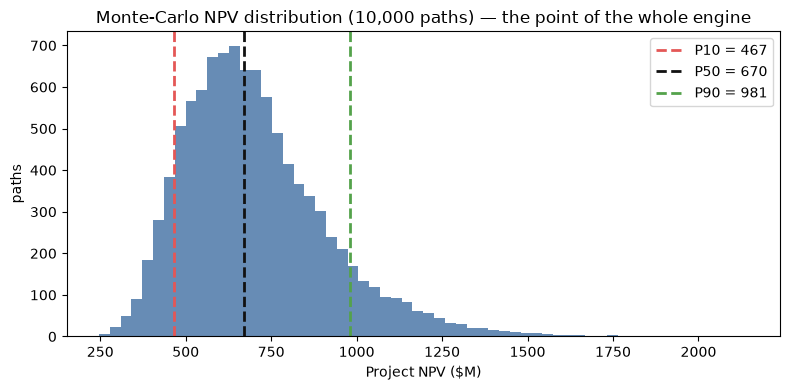

In [7]:
fig, ax = plt.subplots()
ax.hist(project_npv, bins=60, color="#4C78A8", alpha=0.85)
for q, lbl, col in [(p10, "P10", "#E45756"), (p50, "P50", "#111111"), (p90, "P90", "#54A24B")]:
    ax.axvline(q, color=col, lw=2, ls="--", label=f"{lbl} = {q:,.0f}")
ax.set_title("Monte-Carlo NPV distribution (10,000 paths) — the point of the whole engine")
ax.set_xlabel("Project NPV ($M)"); ax.set_ylabel("paths"); ax.legend()
plt.tight_layout(); plt.show()

A spreadsheet reports a **single** NPV; the engine reports the whole
distribution, so we can later constrain **Cash-Flow-at-Risk** (the left tail)
inside the CVXPY allocation. Every bar in that histogram came from a balance
sheet that ties out.

## What's next
- **Pillar 1** — replace the GBM placeholder with the NumPyro HMM/state-space
  driver (regime-aware WTI/rates/inflation with honest P10/P50/P90).
- **Pillar 2** — swap the flat WACC for QuantLib term-structure discounting.
- **Pillar 4** — feed these NPV distributions into the CFaR-constrained allocator.

Each will get its own tutorial notebook, reviewed against textbook-kb.

---
## References (grounded via textbook-kb)
- **Berk & DeMarzo, *Corporate Finance* (2024)** — FCFF identity & depreciation
  tax shield, Eq. 8.6 (p. 254); balance-sheet identity & stockholders' equity
  (pp. 31, 63–64).
- **Subramanyam, *Financial Statement Analysis*, 11e** — equity = contributed
  capital + retained earnings (p. 39).
- **Hilpisch, *Python for Finance* (O'Reilly, 2014)** — Monte-Carlo present-value
  estimator, Eq. 17-1 (p. 511).

*Sources pulled live from the textbook-kb MCP on 2026-07-15.*